In [1]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
import PIL
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [2]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url,  cache_dir='.', untar=True)
# cache_dir indicates where to download data. I specified . which means current directory
# untar true will unzip it

In [3]:
data_dir

'.\\datasets\\flower_photos'

In [4]:
import pathlib
data_dir = pathlib.Path(data_dir)
data_dir

WindowsPath('datasets/flower_photos')

In [5]:
list(data_dir.glob('**/*.jpg'))[:5]

[WindowsPath('datasets/flower_photos/flower_photos/daisy/100080576_f52e8ee070_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/daisy/10140303196_b88d3d6cec.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/daisy/10172379554_b296050f82_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/daisy/10172567486_2748826a8b.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/daisy/10172636503_21bededa75_n.jpg')]

In [6]:
image_count = len(list(data_dir.glob('**/*.jpg')))
print(image_count)

3670


In [7]:
roses = list(data_dir.glob('**/roses/*'))
roses[:5]

[WindowsPath('datasets/flower_photos/flower_photos/roses/10090824183_d02c613f10_m.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/102501987_3cdb8e5394_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/10503217854_e66a804309.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/10894627425_ec76bbc757_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/110472418_87b6a3aa98_m.jpg')]

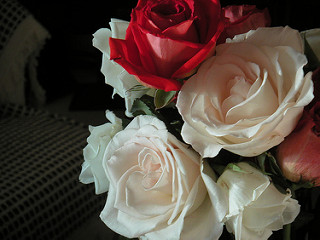

In [8]:
PIL.Image.open(str(roses[1]))

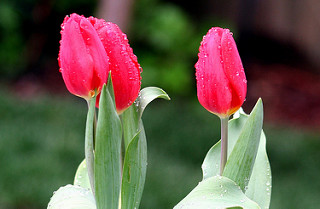

In [9]:
tulips = list(data_dir.glob('**/tulips/*'))
PIL.Image.open(str(tulips[0]))
                        

In [10]:
flowers_images_dict = {
    'roses': list(data_dir.glob('**/roses/*')),
    'daisy': list(data_dir.glob('**/daisy/*')),
    'dandelion': list(data_dir.glob('**/dandelion/*')),
    'sunflowers': list(data_dir.glob('**/sunflowers/*')),
    'tulips': list(data_dir.glob('**/tulips/*')),
}

In [11]:
flowers_label_dict = {
    'roses': 0,
    'daisy': 1,
    'dandelion': 2,
    'sunflowers': 3,
    'tulips': 4,
}

In [12]:
# Use the key 'roses' instead of '**/roses/*'
flowers_images_dict['roses'][:5]

[WindowsPath('datasets/flower_photos/flower_photos/roses/10090824183_d02c613f10_m.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/102501987_3cdb8e5394_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/10503217854_e66a804309.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/10894627425_ec76bbc757_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/110472418_87b6a3aa98_m.jpg')]

In [13]:
str(flowers_images_dict['roses'][:1])

"[WindowsPath('datasets/flower_photos/flower_photos/roses/10090824183_d02c613f10_m.jpg')]"

In [14]:
img = cv2.imread(str(flowers_images_dict['roses'][0]))

In [15]:
img.shape

(240, 179, 3)

In [16]:
cv2.resize(img,(180,180)).shape

(180, 180, 3)

In [17]:
x,y = [],[]
for flowers_name, images in flowers_images_dict.items():
    for image in images:
        img = cv2.imread(str(image))
        resized_img = cv2.resize(img,(180,180))
        x.append(resized_img)
        y.append(flowers_label_dict[flowers_name])

In [18]:
x = np.array(x)
y = np.array(y)

In [19]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, random_state=0)

In [24]:
X_train_scaled = X_train / 255
X_test_scaled = X_test / 255

In [23]:

num_classes = 5
model = Sequential([
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])
              
model.fit(X_train_scaled, y_train, epochs=30)             

Epoch 1/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 44s 454ms/step - accuracy: 0.3863 - loss: 1.4168
Epoch 2/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 36s 413ms/step - accuracy: 0.5785 - loss: 1.0454
Epoch 3/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 13s 147ms/step - accuracy: 0.6613 - loss: 0.8744
Epoch 4/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 13s 148ms/step - accuracy: 0.7555 - loss: 0.6547
Epoch 5/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 13s 152ms/step - accuracy: 0.8176 - loss: 0.4965
Epoch 6/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 13s 149ms/step - accuracy: 0.8961 - loss: 0.3062
Epoch 7/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 13s 147ms/step - accuracy: 0.9430 - loss: 0.1820
Epoch 8/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 13s 148ms/step - accuracy: 0.9746 - loss: 0.1014
Epoch 9/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 13s 146ms/step - accuracy: 0.9778 - loss: 0.0703
Epoch 10/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 13s 146ms/step - accuracy: 0.9935 - loss: 0.0408
Epoch 11/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 13s 146ms/step - accuracy: 0.9916 - loss: 0.0393
Epoch 12/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 13

In [24]:
model.evaluate(X_test_scaled,y_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.6449 - loss: 2.5398


[2.5398285388946533, 0.6448801755905151]

In [25]:
predictions = model.predict(X_test_scaled)
predictions

29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step


array([[  3.4328585,  23.00648  ,  10.559285 , -44.925964 ,  -6.577069 ],
       [  9.575741 ,   2.233169 ,  -8.303443 , -13.133576 ,   7.9371448],
       [ -5.638642 ,   2.9435792,  15.418242 , -17.414715 ,  -1.7332875],
       ...,
       [  3.754904 , -10.333057 ,  -7.105992 ,   7.039951 ,  11.362939 ],
       [  9.730376 ,   3.9994228,   2.8234715,  -9.780384 ,  -7.000941 ],
       [  4.9546347, -17.979414 ,   3.548761 ,  10.947513 ,   4.7971244]],
      shape=(918, 5), dtype=float32)

In [26]:
score = tf.nn.softmax(predictions[0])

In [27]:
np.argmax(score)

np.int64(1)

In [28]:
y_test[0]

np.int64(1)

In [20]:
# Define the image dimensions first
img_height = 180
img_width = 180

# Updated data augmentation sequence without 'experimental'
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal", input_shape=(img_height, img_width, 3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

C:\Users\niran\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


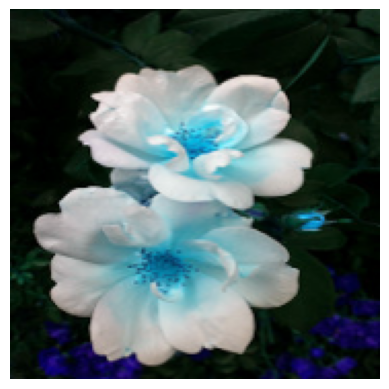

In [21]:
plt.axis('off')
plt.imshow(x[0])

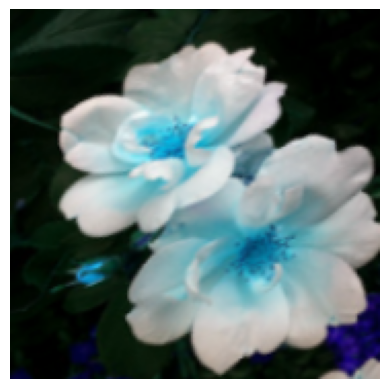

In [22]:
plt.axis('off')
plt.imshow(data_augmentation(x)[0].numpy().astype("uint8"))

In [25]:
num_classes = 5
model = Sequential([
    data_augmentation,
    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes)
])
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])
              
model.fit(X_train_scaled, y_train, epochs=30)    

Epoch 1/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 21s 197ms/step - accuracy: 0.4306 - loss: 1.3220
Epoch 2/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 17s 202ms/step - accuracy: 0.5643 - loss: 1.0780
Epoch 3/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 17s 203ms/step - accuracy: 0.6319 - loss: 0.9425
Epoch 4/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 17s 194ms/step - accuracy: 0.6537 - loss: 0.8688
Epoch 5/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 18s 213ms/step - accuracy: 0.6930 - loss: 0.8107
Epoch 6/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 18s 206ms/step - accuracy: 0.7082 - loss: 0.7699
Epoch 7/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 18s 203ms/step - accuracy: 0.7104 - loss: 0.7309
Epoch 8/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 18s 211ms/step - accuracy: 0.7264 - loss: 0.7025
Epoch 9/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 18s 203ms/step - accuracy: 0.7373 - loss: 0.6715
Epoch 10/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 18s 207ms/step - accuracy: 0.7500 - loss: 0.6456
Epoch 11/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 18s 203ms/step - accuracy: 0.7573 - loss: 0.6246
Epoch 12/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 17

In [ ]:
model.evaluate(X_test_scaled,y_test)

In [ ]:
# 1. Get raw predictions (logits) for the training data
train_predictions = model.predict(X_train_scaled)

# 2. Convert logits to actual predicted class indices
# (Takes the index of the highest score for each image)
train_predicted_labels = np.argmax(train_predictions, axis=1)

# 3. Print the first 10 true labels vs predicted labels to compare
print("True Labels:     ", y_train[:10])
print("Predicted Labels:", train_predicted_labels[:10])

In [27]:
import tensorflow as tf
from tensorflow.keras import layers, Sequential
IMAGE_SHAPE  = (180,180,3)

base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMAGE_SHAPE,
    include_top=False,
    weights='imagenet'
)

C:\Users\niran\AppData\Local\Temp\ipykernel_4716\1889883532.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


In [ ]:
num_classes = 5
model_tf = Sequential([
    data_augmentation,
    layers.Lambda(lambda x: (x * 2.0) - 1.0),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(num_classes)
])
model_tf.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

# Train for fewer epochs (Transfer learning converges much faster!)
model_tf.fit(X_train_scaled, y_train, epochs=10)


Epoch 1/10
